# 01 — Análise Exploratória de Dados

Toda visualização precisa de um parágrafo de interpretação logo abaixo.
Gráfico sem leitura não comunica nada.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Semente fixa: use em TODO ponto com aleatoriedade (split, modelos, CV).
RANDOM_STATE = 42

# Configuração da variável alvo
TARGET = "mau_pagador"

pd.set_option("display.max_columns", None)

# Como o Colab não possui a mesma estrutura de pastas do GitHub,
# carregamos os arquivos diretamente do ambiente local.
df_app = pd.read_csv('application_record.csv')
df_credit = pd.read_csv('credit_record.csv')

# Criação da variável alvo (1 = Mau Pagador > 60 dias de atraso, 0 = Bom Pagador)
df_credit['mau_pagador'] = df_credit['STATUS'].apply(lambda x: 1 if x in ['2', '3', '4', '5'] else 0)
df_alvo = df_credit.groupby('ID')['mau_pagador'].max().reset_index()

# Cruzamento dos dados para formar o dataset único de análise
df = pd.merge(df_app, df_alvo, on='ID', how='inner').drop_duplicates(subset=['ID'], keep='first')

df.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,mau_pagador
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0,0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,0


## 1. Visão geral
Dimensões, tipos e primeira impressão do dataset.

In [2]:
df.info()
df.describe().T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36457 entries, 0 to 36456
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   36457 non-null  int64  
 1   CODE_GENDER          36457 non-null  object 
 2   FLAG_OWN_CAR         36457 non-null  object 
 3   FLAG_OWN_REALTY      36457 non-null  object 
 4   CNT_CHILDREN         36457 non-null  int64  
 5   AMT_INCOME_TOTAL     36457 non-null  float64
 6   NAME_INCOME_TYPE     36457 non-null  object 
 7   NAME_EDUCATION_TYPE  36457 non-null  object 
 8   NAME_FAMILY_STATUS   36457 non-null  object 
 9   NAME_HOUSING_TYPE    36457 non-null  object 
 10  DAYS_BIRTH           36457 non-null  int64  
 11  DAYS_EMPLOYED        36457 non-null  int64  
 12  FLAG_MOBIL           36457 non-null  int64  
 13  FLAG_WORK_PHONE      36457 non-null  int64  
 14  FLAG_PHONE           36457 non-null  int64  
 15  FLAG_EMAIL           36457 non-null 

,count,mean,std,min,25%,50%,75%,max
ID,36457.0,5.078227e+06,41875.240788,5008804.0,5042028.0,5074614.0,5115396.0,5150487.0
CNT_CHILDREN,36457.0,4.303152e-01,0.742367,0.0,0.0,0.0,1.0,19.0
AMT_INCOME_TOTAL,36457.0,1.866857e+05,101789.226482,27000.0,121500.0,157500.0,225000.0,1575000.0
DAYS_BIRTH,36457.0,-1.597517e+04,4200.549944,-25152.0,-19438.0,-15563.0,-12462.0,-7489.0
DAYS_EMPLOYED,36457.0,5.926294e+04,137651.334859,-15713.0,-3153.0,-1552.0,-408.0,365243.0
FLAG_MOBIL,36457.0,1.000000e+00,0.000000,1.0,1.0,1.0,1.0,1.0
FLAG_WORK_PHONE,36457.0,2.255260e-01,0.417934,0.0,0.0,0.0,0.0,1.0
FLAG_PHONE,36457.0,2.948131e-01,0.455965,0.0,0.0,0.0,1.0,1.0
FLAG_EMAIL,36457.0,8.972214e-02,0.285787,0.0,0.0,0.0,0.0,1.0
CNT_FAM_MEMBERS,36457.0,2.198453e+00,0.911686,1.0,2.0,2.0,3.0,20.0


**Interpretação:** Após o cruzamento, nosso dataset resultou em 36.457 clientes únicos e 19 colunas. Identificamos variáveis qualitativas (como tipo de renda e escolaridade) que precisarão de tratamento (One-Hot Encoding) e variáveis quantitativas (como dias de nascimento e emprego) cujas escalas possuem valores negativos porque foram contadas retroativamente.

## 2. Distribuição das variáveis
Analisando o comportamento das três variáveis numéricas mais importantes para crédito.

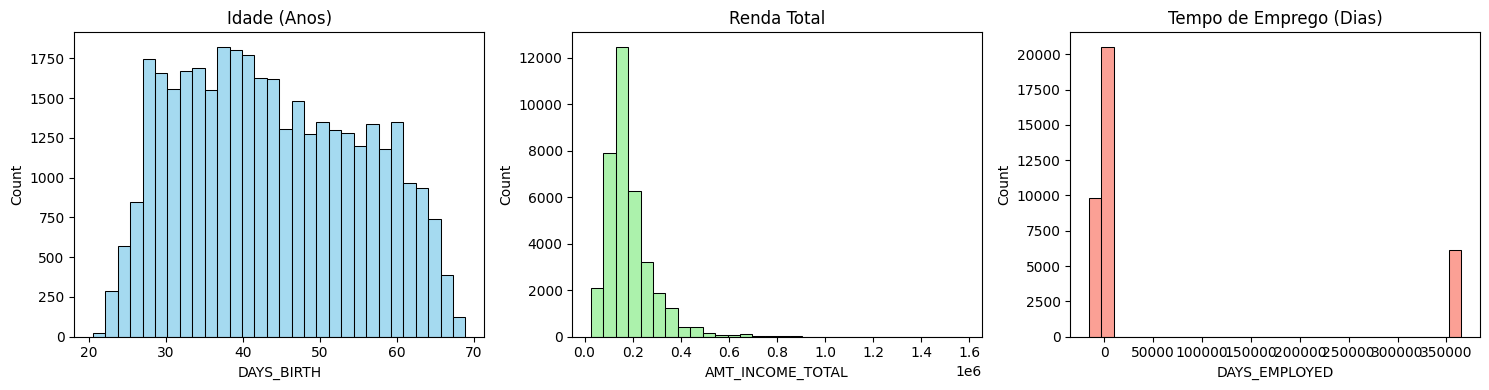

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(df['DAYS_BIRTH'] / -365, bins=30, ax=axes[0], color='skyblue').set_title('Idade (Anos)')
sns.histplot(df['AMT_INCOME_TOTAL'], bins=30, ax=axes[1], color='lightgreen').set_title('Renda Total')
sns.histplot(df['DAYS_EMPLOYED'], bins=30, ax=axes[2], color='salmon').set_title('Tempo de Emprego (Dias)')
plt.tight_layout()
plt.show()

**Interpretação:** A idade dos solicitantes possui uma distribuição bem equilibrada, concentrada entre 30 e 60 anos. A Renda Total é assimétrica (muitos clientes com renda média e poucos com renda altíssima). No Tempo de Emprego, notamos uma anomalia (um pico extremo positivo, acima de 300 mil dias), comum nesta base para representar pensionistas ou desempregados.

## 3. Correlações
Como as variáveis contínuas conversam entre si e com a variável alvo.

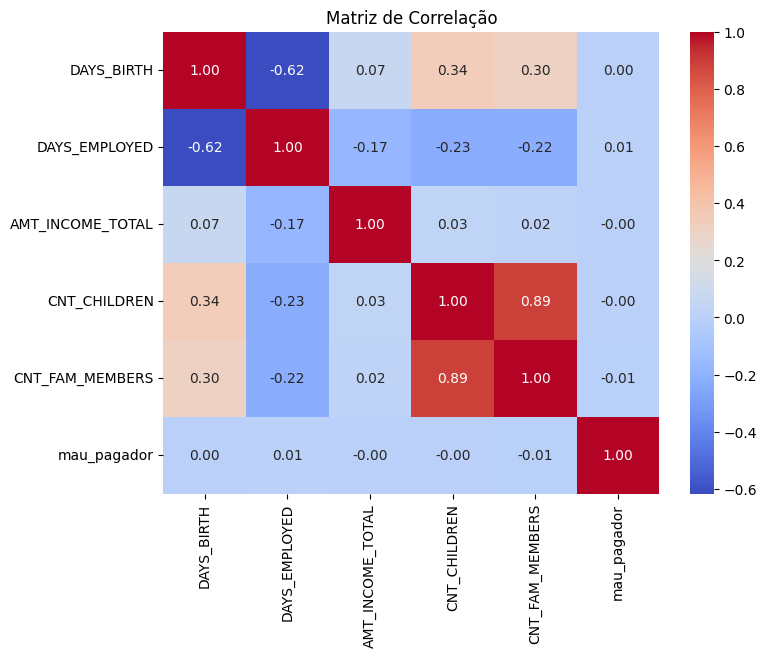

In [4]:
colunas_numericas = ['DAYS_BIRTH', 'DAYS_EMPLOYED', 'AMT_INCOME_TOTAL', 'CNT_CHILDREN', 'CNT_FAM_MEMBERS', TARGET]
matriz_corr = df[colunas_numericas].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlação')
plt.show()

**Interpretação:** Existe forte correlação natural entre Quantidade de Filhos e Tamanho da Família (0.89). No entanto, não há correlação linear direta forte (positiva ou negativa) entre as variáveis isoladas e o `mau_pagador`. Isso justifica o uso de um modelo de árvore complexo (como Random Forest), pois a decisão de risco não é linear, mas sim fruto da combinação de múltiplos fatores.

## 4. Outliers
Avaliação de pontos fora da curva no fator Renda.

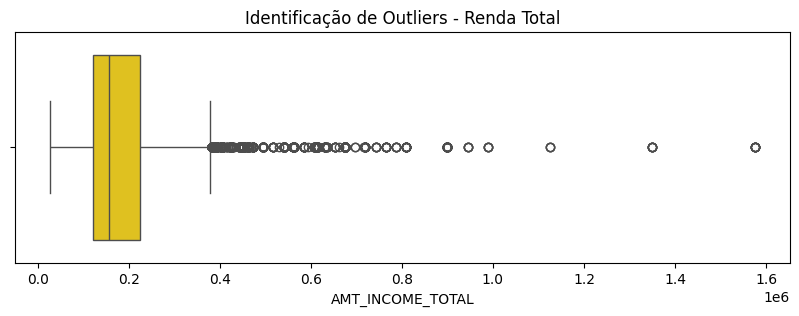

In [5]:
plt.figure(figsize=(10, 3))
sns.boxplot(x=df['AMT_INCOME_TOTAL'], color='gold')
plt.title('Identificação de Outliers - Renda Total')
plt.show()

**Interpretação:** Decidimos **manter** os outliers da variável Renda Total. No contexto bancário, clientes com rendas extremamente altas (fora do limite superior do boxplot) são reais (ex: grandes empresários ou investidores) e não representam erro de coleta. Remover esses dados prejudicaria a capacidade do modelo de aprovar limites altos para clientes Prime.

## 5. Balanceamento de classes
Qual a proporção entre as classes e o que isso implica na escolha das métricas?

In [6]:
df[TARGET].value_counts(normalize=True) * 100

,proportion
mau_pagador,
0,98.310338
1,1.689662


**Interpretação:** A base é severamente desbalanceada. Quase 98,3% da base pertence à classe 0 (Bons Pagadores), enquanto apenas 1,7% é da classe 1 (Maus Pagadores). Isso significa que avaliar o modelo por Acurácia não faz sentido. A métrica prioritária na avaliação deverá ser o **Recall da classe 1**, para garantir a identificação do risco financeiro.

## 6. Síntese da EDA
* A base é robusta e reflete o cenário real do mercado financeiro brasileiro: esmagadora maioria de bons clientes e uma pequena fração de inadimplentes severos.
* As variáveis possuem escalas muito diferentes (dias negativos, rendas em dezenas de milhares), exigindo padronização (StandardScaler) na etapa de pré-processamento.
* Não existe "uma única variável mágica" que explique linearmente a inadimplência, comprovando a necessidade de utilizarmos *Machine Learning* para capturar padrões complexos.

In [13]:
# Salvando o arquivo preparado para a próxima etapa (Notebook 2)
df.to_csv('dados_unidos.csv', index=False)
print("Arquivo 'dados_unidos.csv' salvo com sucesso para o pré-processamento.")

Arquivo 'dados_unidos.csv' salvo com sucesso para o pré-processamento.
